# SPARC-4 products
***

This notebook shows an example for viewing and accessing the SPARC4 data products.

* Eder Martioli, LNA 18 Apr 2024
* Fernando Falkenberg INPE 09 Oct 2025

In [1]:
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sparc4.product_plots as s4plt
import sparc4.pipeline_lib as s4pipelib

### Set paths to example files 
Below we set the paths to the files, which are sparc4-pipeline products.

In [2]:
path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250701'
object = 'V2400_Oph'
channel = '2'

In [3]:
db_example = f'{path}{date}/sparc4acs{channel}/{date}_sparc4acs{channel}_db.csv'
# Esse arquivo é uma tabela que contém informações de todas as imagens daquela noite, naquele canal, por exemplo, diretório, tempo de exposição, posição da lâmina, etc.

phot_lightcurve_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_S+N_lc.fits'
# Esse arquivo contém várias tabelas dentro dele, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela, estão informações de cada uma das fontes detectadas pelo pipeline, para cada imagem daquele objeto, por exemplo, RA, Dec, magnitude (com seu erro), fwhm, etc.

polar_stack_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_stack.fits'
# Esse arquivo contém várias tabelas dentro dele, duas para cada abertura em que os dados do objeto foram processados (sendo uma para o feixe ordinário e a outra para o feixe extraordinário). Cada tabela contém uma linha para cada fonte identificada pelo pipeline. Para cada linha, existem informações como RA, Dec, magnitude (com seu erro), fwhm, etc. É uma versão do arquivo logo acima, só que para apenas uma imagem stack.

polar_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_polar.fits'
# Esse arquivo contém várias tabelas, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela existe uma linha para cada fonte detectada pelo pipeline. Em cada linha estão os resultados da polarimetria para aquela fonte, por exemplo, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... Além disso, também estão as contagens para cada posição de lâmina, para cada fonte, para cada imagem, com seus erros. É nesse arquivo que estão os dados importantes.

polar_time_series_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_ts.fits'
# Esse arquivo contém uma tabela com os dados da série temporal polarimétrica das fontes detectadas pelo pipeline, por exemplo, RA, Dec, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... O resultado aqui é para cada conjunto de uma medida polarimétrica.

# DB product example
***
In this simple example, we just read the database created by the `sparc4-pipeline` and print it as a pandas table. It's an easy way to quickly access the log of observations.

In [4]:
db = ascii.read(db_example)
pd.DataFrame(np.array(db))

,FILE,DATE-OBS,EXPTIME,RA,DEC,OBJECT,OBSTYPE,INSTMODE,CHANNEL,VBIN,...,VCLKAMP,CCDSERN,PREAMP,READRATE,EMMODE,EMGAIN,WPPOS,WPSEL,CALW,ASEL
0,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:20.327000,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,1,L2,None,True
1,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:21.647063,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,1,L2,None,True
2,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:22.967126,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,1,L2,None,True
3,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:24.287189,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,1,L2,None,True
4,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:27.114000,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,2,L2,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T04:59:06.324000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,8,L4,None,True
654,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T04:59:48.869000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,9,L4,None,True
655,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T05:00:31.394000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,10,L4,None,True
656,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T05:01:13.999000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,11,L4,None,True


# POLAR products example
***
In this example we show how to work with the polarimetric products of SPARC4

We start by reading the science image FITS file and showing its information. 

In [5]:
hdul = fits.open(polar_stack_example)
hdul.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs2/20250701_s4c2_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_stack.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     157   (1024, 1024)   float64   
  1  CATALOG_POL_S_AP005    1 TableHDU        51   111R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  2  CATALOG_POL_N_AP005    1 TableHDU        51   111R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  3  CATALOG_POL_S_AP008    1 TableHDU        51   111R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  4  CATALOG_POL_N_AP008    1 TableHDU        51   111R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  5  CATALOG_POL_S_AP010    1 TableHDU        51   111R x 13C   [I11, D

Then we plot the science frame using the `sparc4.product_plots` library

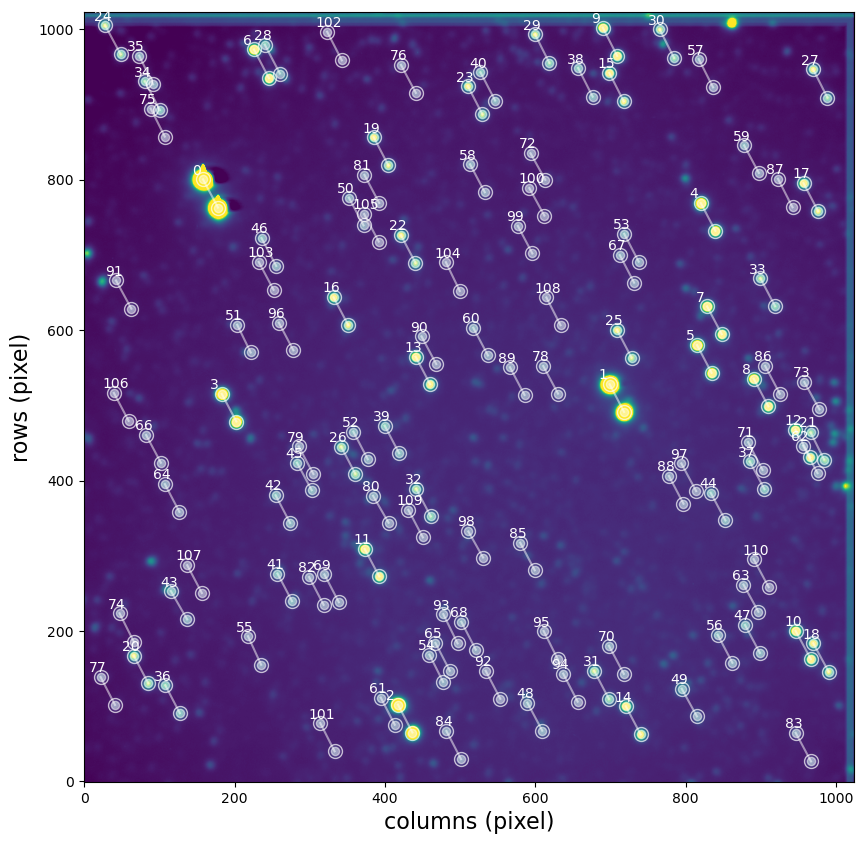

In [6]:
s4plt.plot_sci_polar_frame(polar_stack_example)

Now print one of the catalogs to see its contents

In [7]:
catalog = 'CATALOG_POL_N_AP010'
pd.DataFrame(hdul[catalog].data)

,SRCINDEX,RA,DEC,X,Y,FWHMX,FWHMY,MAG,EMAG,SKYMAG,ESKYMAG,APER,FLAG
0,0,258.181391,-24.224304,177.936091,763.022539,11.155057,11.155057,-11.957160,0.000406,-9.583074,0.001276,10,0
1,1,258.125092,-24.248652,718.015141,491.282224,10.514521,10.514521,-11.612152,0.000483,-9.677142,0.000950,10,0
2,2,258.153069,-24.289258,436.574442,64.925858,8.902475,8.902475,-10.605449,0.000888,-9.661615,0.000920,10,0
3,3,258.178160,-24.251018,202.423440,478.526376,8.972065,8.972065,-10.000385,0.001371,-9.620936,0.001039,10,0
4,4,258.113193,-24.225758,839.402989,732.210373,8.891305,8.891305,-9.812838,0.001573,-9.620367,0.001037,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,106,258.192923,-24.251226,59.138958,479.434490,9.034109,9.034109,-6.539446,0.023143,-9.592141,0.000845,10,0
107,107,258.182350,-24.272504,156.518318,250.428260,9.063787,9.063787,-6.401623,0.024762,-9.620475,0.000672,10,0
108,108,258.134025,-24.238011,633.485736,606.637940,8.908139,8.908139,-6.554775,0.024733,-9.653907,0.000937,10,0
109,109,258.152251,-24.264924,450.487193,324.376054,8.935525,8.935525,-6.592612,0.023228,-9.669431,0.000854,10,0


Below we select the source with its index number assigned as the main target to be analyzed. Then we select other stars as comparisons for differential photometry. All indices are displayed in the image above.  

After selecting the stars we use the function `s4plt.plot_light_curve` to produce plots of the lightcurve data.

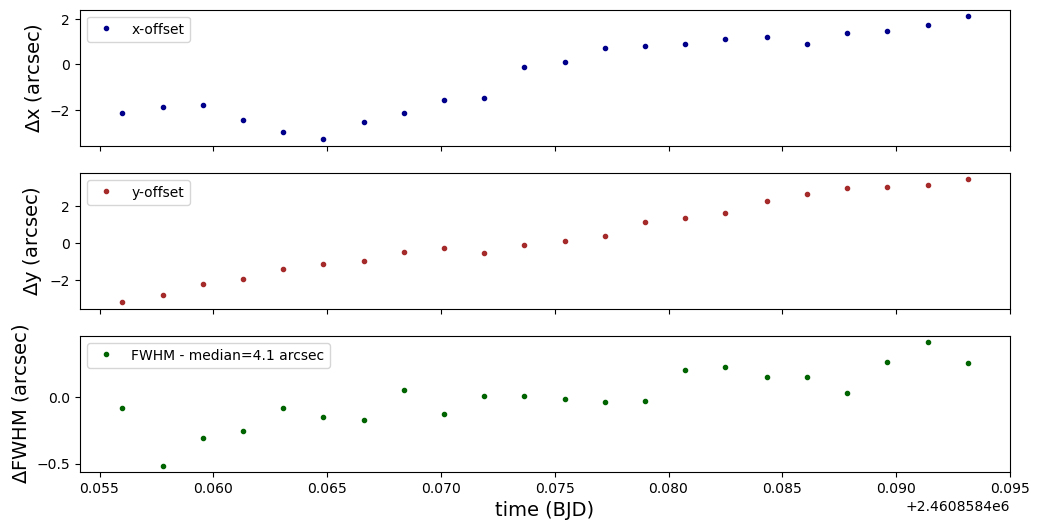

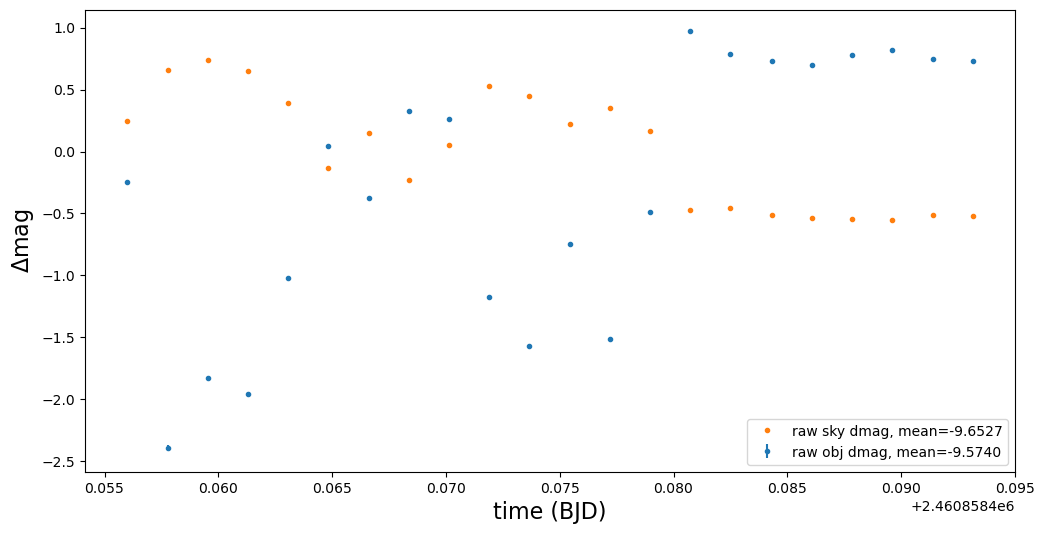

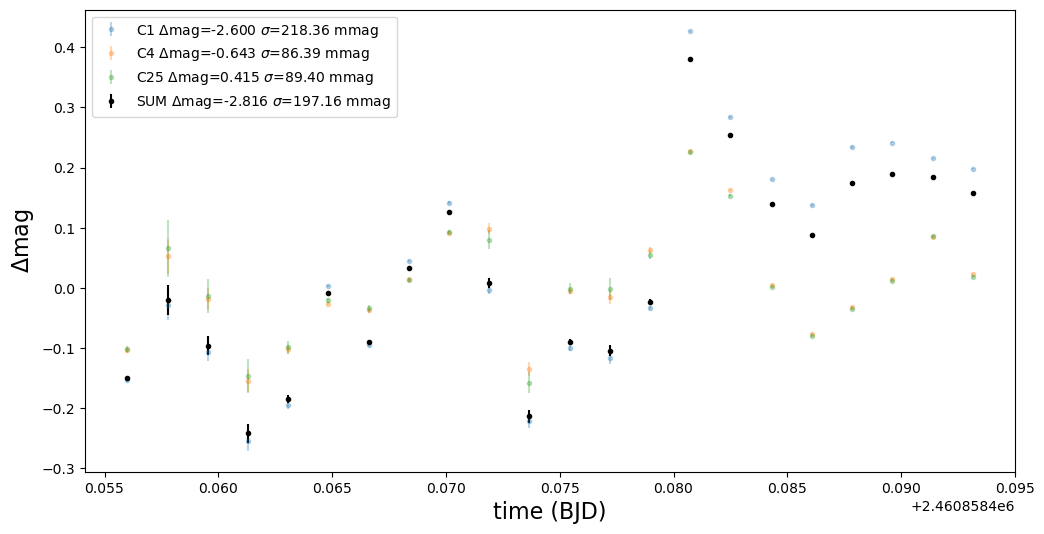

       TIME                x          ...       diffmagsum     
------------------ ------------------ ... ---------------------
2460858.4560016026 450.47942050486074 ...  -0.14985179456396125
2460858.4577726186 451.22942050486074 ... -0.019694104877252094
 2460858.459537409 451.47942050486074 ...  -0.09596479086402177
2460858.4613030204 449.47942050486074 ...   -0.2419600769425747
 2460858.463069234 447.97942050486074 ...    -0.184276246113237
 2460858.464833966 446.97942050486074 ...  -0.00830836708159488
 2460858.466599219 449.22942050486074 ...    -0.089950411925523
               ...                ... ...                   ...
2460858.4824949303 460.22942050486074 ...   0.25412759162212417
2460858.4843099266 460.47942050486074 ...   0.13958808231678432
 2460858.486078825 459.47942050486074 ...   0.08877434987379118
 2460858.487844737 460.97942050486074 ...   0.17380084550693908
2460858.4896117486 461.22942050486074 ...   0.18969603626080023
2460858.4913803344 461.97942050486074 ..

In [8]:
catalog = 'CATALOG_PHOT_AP010'
target=13
comps=[1,4,25]

lc = s4plt.plot_light_curve(phot_lightcurve_example, target=target, comps=comps, nsig=10,
                            plot_coords=True, plot_rawmags=True, plot_sum=True,
                            plot_comps=True, catalog_name=catalog)

print(lc)

Now we open a polarimetry FITS product and print its basic information

In [9]:
polar = fits.open(polar_example)
polar.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs2/20250701_s4c2_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_polar.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     159   ()      
  1  POLARIMETRY_AP005    1 BinTableHDU    258   111R x 123C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  2  POLARIMETRY_AP008    1 BinTableHDU    258   111R x 123C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 

Below we print one of the catalog extensions

In [10]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data)

ValueError: Big-endian buffer not supported on little-endian compiler

ValueError: Big-endian buffer not supported on little-endian compiler

Then we can print all column names to check the data available in each catalog

In [11]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data).columns

Index(['APERINDEX', 'APER', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2',
       'FWHM',
       ...
       'FE0019', 'EFE0019', 'FO0020', 'EFO0020', 'FE0020', 'EFE0020', 'FO0021',
       'EFO0021', 'FE0021', 'EFE0021'],
      dtype='object', length=123)

Finally, we can select the source of interest and then we get the polarimetry results using the function `get_polarimetry_results` from `sparc4.pipeline_lib` library:

2025-11-03 11:58:27,484 astropop - INFO - Normalization disabled.  [__init__]


2025-11-03 11:58:27,484 | INFO | Normalization disabled.


/home/fernando/anaconda3/lib/python3.12/site-packages/astropop/math/_deriv.py:29: RuntimeWarning: invalid value encountered in log
  return np.log(x)*np.power(x, y)
2025-11-03 11:58:27,492 root - INFO - Source index: i=13   [pipeline_lib]


2025-11-03 11:58:27,492 | INFO | Source index: i=13 


2025-11-03 11:58:27,493 root - INFO - Source RA=258.1517323259767 Dec=-24.24579537491232 mag=-13.2332+-0.0005  [pipeline_lib]


...

2025-11-03 11:58:27,591 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-03 11:58:27,815 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-03 11:58:27,815 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-03 11:58:27,821 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-03 11:58:27,821 | INFO | Substituting symbol \perp from STIXGeneral


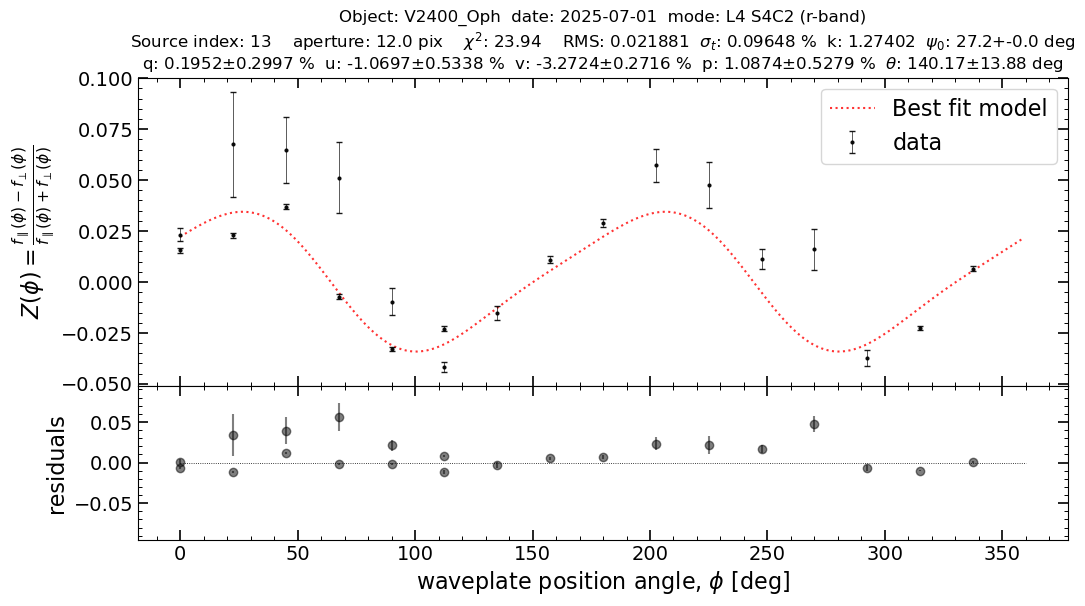

In [12]:
source_index = target

pol_results = s4pipelib.get_polarimetry_results(polar_example,
                                                source_index=source_index,
                                                min_aperture=5,
                                                max_aperture=21,
                                                plot=True,
                                                verbose=True)

Below we print all variables names for the measurements available in the polar product

In [13]:
for key in pol_results.keys():
    print(key, ":", pol_results[key])

POLAR_PRODUCT : /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs2/20250701_s4c2_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_polar.fits
SOURCE_INDEX : 13
POLARIMETRY_SUCCESS : True
APERTURE_INDEX : 4
APERTURE_RADIUS : 12.0
NEXPS : 22
MAG : -13.2332+-0.0005
RA : 258.1517323259767
DEC : -24.24579537491232
FWHM : 8.682503033517396
X1 : 440.85014865840645
Y1 : 564.7305975919191
X2 : 460.10869235131497
Y2 : 528.0514637745466
WAVEPLATE_ANGLES : [  0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5   0.   22.5  45.   67.5  90.  112.5]
ZI : [0.023+-0.003, 0.07+-0.03, 0.06+-0.02, 0.05+-0.02, -0.010+-0.007,
 -0.042+-0.002, -0.015+-0.004, 0.011+-0.002, 0.029+-0.002, 0.057+-0.008,
 0.05+-0.01, 0.011+-0.005, 0.02+-0.01, -0.037+-0.004, -0.022+-0.001,
 0.007+-0.001, 0.016+-0.001, 0.023+-0.001, 0.037+-0.001, -0.007+-0.001,
 -0.033+-0.001, -0.023+-0.001]
FO : [3620+-10, 520+-20, 870+-20, 770+-20, 1720+-10, 4430+-10, 3090+-10,
 6170+-10, 5790+

And below we show a simple example how to get one of these measurements out. For instance, we're getting the total polarization and the polarization angle. 

In [14]:
p = pol_results["P"]*100
pa = pol_results["THETA"]
print("Polarization: {} %  Angle of polarization: {} deg".format(p,pa) )

Polarization: 1.1+-0.5 %  Angle of polarization: 140+-10 deg deg


Finally, we show below an example of a polarimetric time series product. 

In [15]:
polar_ts = fits.open(polar_time_series_example)
pd.DataFrame(polar_ts[1].data)

ValueError: Big-endian buffer not supported on little-endian compiler

ValueError: Big-endian buffer not supported on little-endian compiler

In [16]:
pd.DataFrame(polar_ts[1].data).columns

Index(['TIME', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2', 'FWHM', 'MAG',
       'EMAG', 'Q', 'EQ', 'U', 'EU', 'V', 'EV', 'P', 'EP', 'THETA', 'ETHETA',
       'K', 'EK', 'ZERO', 'EZERO', 'NOBS', 'NPAR', 'CHI2', 'RMS', 'TSIGMA'],
      dtype='object')

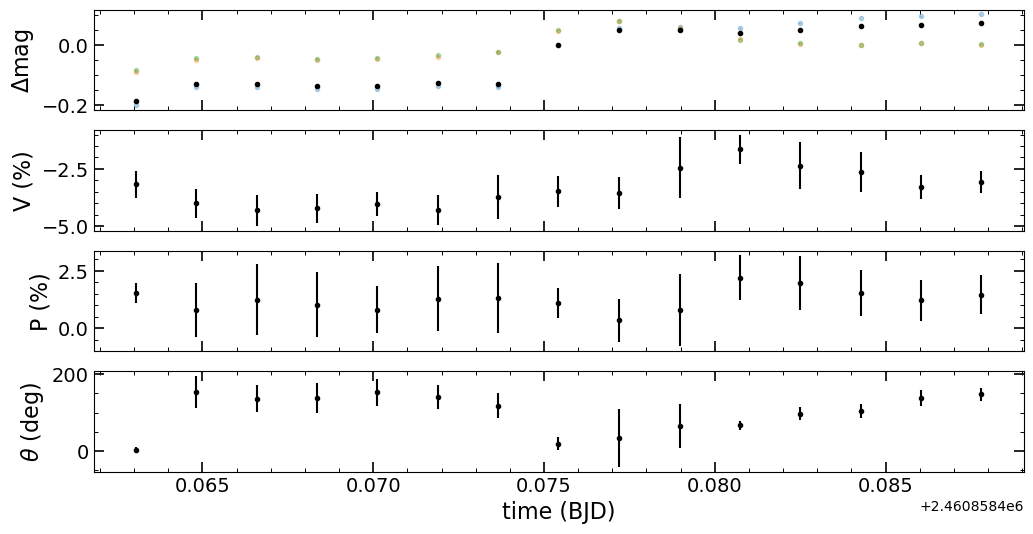

diffmag_C00000,diffmag_err_C00000,diffmag_C00001,diffmag_err_C00001,diffmag_C00002,diffmag_err_C00002,TIME,x1,y1,x2,y2,fwhm,mag,mag_err,magsum,magsum_err,diffmagsum,polarization_1,polarization_1_err,polarization_2,polarization_2_err
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-0.20071751061596466,0.001525844961968386,-0.09069121083834908,0.0017605368892078556,-0.08381712175289202,0.0027616889744107947,2460858.463052296,440.85014865840645,564.7305975919191,460.10869235131497,528.0514637745466,8.393919373445513,-11.366788203208511,0.001513851797890541,-14.244705989251013,0.002485835308237224,-0.18880627464775834,0.015358211243528397,0.004487694331876867,1.8220314632033108,8.35696656703829
-0.1394355975128363,0.0013866099466268832,-0.04970071650014418,0.0016143089259892179,-0.043129093556645515,0.002575838585173016,2460858.464820309,441.60014865840645,565.9805975919191,460.85869235131497,529.3014637745466,8.379696943108243,-11.470502200145411,0.0013741266559809796,-14.290876753485616,0.00234498457765649,-0.131263041945461,0.007860085478327178,0.01164526550869709,153.38412495089923,42.37289714813879
-0.1390791353362566,0.0013229486328132536,-0.044945401551590436,0.0015416803372961503,-0.03976509607254819,0.002464320389309094,2460858.4665853307,441.85014865840645,567.7305975919191,461.10869235131497,531.0514637745466,8.471452635859631,-11.517006161589936,0.0013106893864612043,-14.33628240489275,0.0022463584587697504,-0.130164731908069,0.012422268300857377,0.015337336253126253,135.93996902712428,35.31141062290014
-0.1458619615698762,0.0012869805919436,-0.0505348341059797,0.001497096728004414,-0.04665497648758077,0.0023846768112944336,2460858.4683512663,439.85014865840645,568.4805975919191,459.10869235131497,531.8014637745466,8.508817542334409,-11.526759906431943,0.00127483873500999,-14.3526647032668,0.0021699446422710406,-0.13679328544011327,0.01027257563493976,0.013980595521205454,137.92867853708356,38.92354226592373
-0.14655947500883748,0.001193982189469594,-0.046390478293236725,0.0013883147983297633,-0.04241583575022112,0.0022122954161985843,2460858.4701183075,438.35014865840645,570.2305975919191,457.60869235131497,533.5514637745466,8.562579353164184,-11.591301784696588,0.0011821211974491835,-14.417008897731947,0.0020137107240587484,-0.13659560164061446,0.008072582670656593,0.01009583454910778,152.54624333750795,35.76809057082068
-0.13743604281211041,0.0012159065328947883,-0.03951393273382564,0.0014163483536652293,-0.035187126553530845,0.0022664246689537413,2460858.4718836467,437.35014865840645,570.9805975919191,456.60869235131497,534.3014637745466,8.583086544563727,-11.56433885708954,0.0012037500664696598,-14.381317588306764,0.0020673919483570054,-0.1278672198224804,0.012745793515910878,0.014086404332625528,140.69676674786075,31.608166522561067
-0.14187278244364343,0.0013169411831969033,-0.025618566544574506,0.001538326718523331,-0.023476096626749765,0.0024689710617019933,2460858.4736491134,439.60014865840645,571.4805975919191,458.85869235131497,534.8014637745466,8.634962629713414,-11.48397197984716,0.0013045177511188286,-14.302148681552278,0.0022563912753537025,-0.12906519031037433,0.013264223957735632,0.015094596003804943,117.52873622327232,32.54660408964618
0.0,0.0010031699523299596,0.04772821269965988,0.0011933547364534351,0.048917672066908224,0.001974446216453349,2460858.475415987,440.85014865840645,572.9805975919191,460.10869235131497,536.3014637745466,8.693508951144128,-11.792828846932252,0.0009898584061466512,-14.481940358326996,0.0018410389320388965,0.0,0.0109425542861327,0.006552320909600531,18.84478832329265,17.125469347870563
0.05446004151301054,0.0009183545717505517,0.08010743882552518,0.0011017967080160856,0.07907974202445622,0.001844349015464784,2460858.477181465,442.60014865840645,573.4805975919191,461.85869235131497,536.8014637745466,8.70287647671244,-11.89683474487923,0.0009046504654485755

In [17]:
s4plt.plot_polar_time_series(polar_time_series_example, 
                             target=target, 
                             comps=comps, 
                             plot_total_polarization=True, 
                             plot_polarization_angle=True)